# Curved Multi-Planar Reconstruction (CMPR) — RCA experiment

This notebook tests whether **VMTK** can generate a curved MPR (CMPR) along the **Right Coronary Artery (RCA)** for patient `Normal_1`, using:

- CTA/mask volume: `data cmpr/Normal_1.nrrd`
- Block 2 merged centerline table: `data cmpr/total_df_Normal_1.xlsx` (`gd`, `Area`, `pct_AS`, …)
- VMTK centerlines: `centerline_RCA.vtp`, `centerline_LCA.vtp`

Run cells **in order**. Cell 4 requires a working VMTK installation (`vmtk`, `vtk`).

## Cell 1 — Sanity check of the medical image

Read the NRRD **header** and load only the central **axial** slice (via **SimpleITK** region I/O). This avoids loading the full CTCA into RAM — `nrrd.read()` on the whole volume can crash the Jupyter kernel on large files.

DATA_DIR: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\data cmpr
NRRD:     C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\data cmpr\Normal_1.nrrd
NRRD header type:     int32
NRRD header encoding: gzip
NRRD header sizes:    [512, 512, 204]
Loader:     SimpleITK (header + single-slice extract)
Shape:      (204, 512, 512)  (z, y, x)
Dtype:      int32  (slice; volume pixel type: 32-bit signed integer)
Spacing:    (0.6250000000000001, 0.41601600000000005, 0.41601600000000005)  (z, y, x)


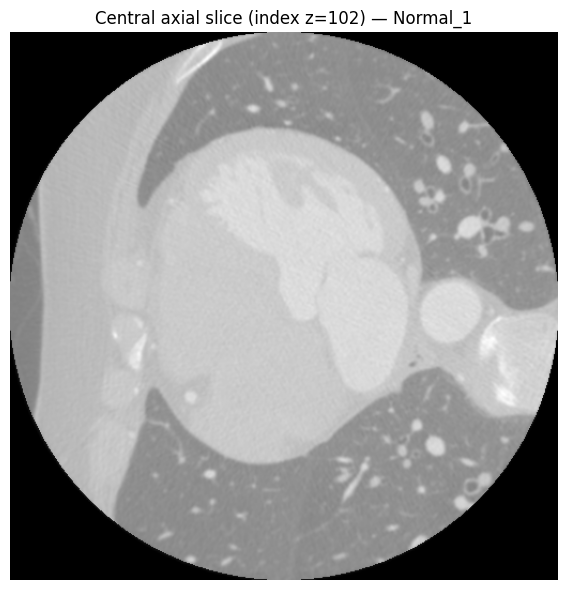

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Resolve experiment data folder (notebook dir or repo root) ---
def resolve_data_cmpr_dir() -> Path:
    rel = Path("data cmpr")
    for base in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        candidate = (base / rel).resolve()
        if (candidate / "Normal_1.nrrd").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find 'data cmpr/Normal_1.nrrd'. "
        "Run this notebook from notebooks/experiments/ or set DATA_DIR manually."
    )

DATA_DIR = resolve_data_cmpr_dir()
EXPERIMENTS_DIR = DATA_DIR.parent
NRRD_PATH = DATA_DIR / "Normal_1.nrrd"

print(f"DATA_DIR: {DATA_DIR}")
print(f"NRRD:     {NRRD_PATH}")

%matplotlib inline


def read_nrrd_header(path: Path) -> dict:
    try:
        import nrrd

        return dict(nrrd.read_header(str(path)))
    except ImportError:
        return {}
    except Exception as exc:
        print(f"Warning: pynrrd header read failed ({exc}); using SimpleITK metadata.")
        return {}


def load_central_axial_slice_sitk(path: Path) -> tuple[np.ndarray, tuple[int, int, int], tuple[float, float, float], str]:
    """Load one axial slice without reading the full volume (ITK region I/O)."""
    import SimpleITK as sitk

    reader = sitk.ImageFileReader()
    reader.SetFileName(str(path))
    reader.ReadImageInformation()

    size_xyz = tuple(int(v) for v in reader.GetSize())  # (x, y, z)
    spacing_xyz = tuple(float(v) for v in reader.GetSpacing())
    pixel_type = sitk.GetPixelIDValueAsString(reader.GetPixelID())

    if len(size_xyz) != 3:
        raise ValueError(f"Expected a 3D volume, got ITK size {size_xyz}")

    z_mid = size_xyz[2] // 2
    reader.SetExtractIndex([0, 0, z_mid])
    reader.SetExtractSize([size_xyz[0], size_xyz[1], 1])

    slice_img = reader.Execute()
    axial_slice = np.asarray(sitk.GetArrayFromImage(slice_img))[0]  # (y, x)
    return axial_slice, size_xyz, spacing_xyz, pixel_type


nrrd_header = read_nrrd_header(NRRD_PATH)
if nrrd_header:
    sizes_hdr = nrrd_header.get("sizes")
    if sizes_hdr is None:
        sizes_hdr = nrrd_header.get("dimension")
    print(f"NRRD header type:     {nrrd_header.get('type', '?')}")
    print(f"NRRD header encoding: {nrrd_header.get('encoding', '?')}")
    if sizes_hdr is not None:
        print(f"NRRD header sizes:    {list(map(int, np.asarray(sizes_hdr).ravel()))}")

axial_slice, size_xyz, spacing_xyz, pixel_type = load_central_axial_slice_sitk(NRRD_PATH)
volume_shape_zyx = (size_xyz[2], size_xyz[1], size_xyz[0])
spacing_zyx = (spacing_xyz[2], spacing_xyz[1], spacing_xyz[0])
z_mid = size_xyz[2] // 2

print(f"Loader:     SimpleITK (header + single-slice extract)")
print(f"Shape:      {volume_shape_zyx}  (z, y, x)")
print(f"Dtype:      {axial_slice.dtype}  (slice; volume pixel type: {pixel_type})")
print(f"Spacing:    {spacing_zyx}  (z, y, x)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(axial_slice.T, cmap="gray", origin="lower")
ax.set_title(f"Central axial slice (index z={z_mid}) — Normal_1")
ax.axis("off")
plt.tight_layout()
plt.show()

## Cell 2 — RCA path from Block 2 `total_df`

Load `total_df_Normal_1.xlsx` (merged Block 2 table with per-branch geodesic distance `gd`, reference areas, and `%AS`). Filter **RCA** rows with SCCT-18 `Segment_ID` **{1, 2, 3, 4}** (proximal/mid/distal RCA and R-PDA), then pick **one continuous branch** (`Branch_ID`, preferring `RCA_B01`) for CMPR — the unified table is not a single ordered path across branches.

In [2]:
import re

import numpy as np
import pandas as pd

SAMPLE_ID = "Normal_1"
TOTAL_DF_PATH = DATA_DIR / f"total_df_{SAMPLE_ID}.xlsx"
RCA_SCCT_SEGMENTS = [1, 2, 3, 4]  # Proximal RCA, Mid RCA, Distal RCA, Right PDA

if not TOTAL_DF_PATH.is_file():
    raise FileNotFoundError(f"Missing Block 2 merged table: {TOTAL_DF_PATH}")

total_df = pd.read_excel(TOTAL_DF_PATH)
total_df["Segment_ID"] = pd.to_numeric(total_df["Segment_ID"], errors="coerce").fillna(0).astype(int)

required_cols = {"Artery_Type", "Segment_ID", "Branch_ID", "Px", "Py", "Pz"}
missing = required_cols - set(total_df.columns)
if missing:
    raise KeyError(f"total_df missing columns: {sorted(missing)}")

print(f"total_df: {total_df.shape[0]} rows × {total_df.shape[1]} columns")
print("Columns:", list(total_df.columns))
print(f"Artery_Type counts:\n{total_df['Artery_Type'].astype(str).str.upper().value_counts()}")


def filter_artery(df: pd.DataFrame, artery: str) -> pd.DataFrame:
    mask = df["Artery_Type"].astype(str).str.upper() == artery.upper()
    return df.loc[mask].copy()


def _branch_sort_key(branch_id) -> tuple:
    s = str(branch_id).strip() if branch_id is not None else ""
    m = re.search(r"_B(\d+)$", s, flags=re.IGNORECASE)
    if m:
        return (s[: m.start()].upper(), int(m.group(1)))
    return (s.upper(), 0)


def geodesic_mm_along_branch(df: pd.DataFrame) -> np.ndarray:
    """Cumulative arc length (mm); uses Block 2 ``gd`` when present."""
    if "gd" in df.columns:
        gd = pd.to_numeric(df["gd"], errors="coerce").to_numpy(dtype=float)
        if len(gd) and np.all(np.isfinite(gd)):
            return gd
    xyz = df[["Px", "Py", "Pz"]].to_numpy(dtype=float)
    if len(xyz) <= 1:
        return np.zeros(len(xyz), dtype=float)
    step = np.linalg.norm(np.diff(xyz, axis=0), axis=1)
    return np.concatenate([[0.0], np.cumsum(step)])


def sort_single_branch(df: pd.DataFrame) -> pd.DataFrame:
    """Order one branch path (ostium → distal) using ``gd`` or reconstructed arc length."""
    out = df.copy()
    out["_gd_sort"] = geodesic_mm_along_branch(out)
    return out.sort_values("_gd_sort", ascending=True).drop(columns="_gd_sort").reset_index(drop=True)


def select_rca_main_branch(df_rca_segments: pd.DataFrame, segments: list[int]) -> tuple[str, pd.DataFrame]:
    """Pick one ``Branch_ID`` that best covers RCA segments 1–4 for a continuous CMPR path."""
    target = set(int(s) for s in segments)
    candidates: list[tuple[tuple, str, pd.DataFrame]] = []

    for branch_id, grp in df_rca_segments.groupby("Branch_ID", sort=False):
        segs = set(pd.to_numeric(grp["Segment_ID"], errors="coerce").fillna(0).astype(int))
        overlap = target & segs
        if not overlap:
            continue
        ordered = sort_single_branch(grp)
        gd = geodesic_mm_along_branch(ordered)
        span = float(gd[-1] - gd[0]) if len(gd) else 0.0
        has_seg1 = 1 in overlap
        # Prefer: covers seg 1, more SCCT segments, longer path, lower B-index (B01 trunk)
        score = (
            int(has_seg1),
            len(overlap),
            span,
            -_branch_sort_key(branch_id)[1],  # higher B01 preference via negated index
        )
        candidates.append((score, str(branch_id), ordered))

    if not candidates:
        raise ValueError(
            f"No RCA branch contains Segment_ID in {sorted(target)}. "
            f"Available RCA segments: {sorted(df_rca_segments['Segment_ID'].unique())}"
        )

    candidates.sort(key=lambda x: x[0], reverse=True)
    _, best_id, best_df = candidates[0]
    return best_id, best_df


# --- Split arteries ---
df_rca_tree = filter_artery(total_df, "RCA")
df_lca_tree = filter_artery(total_df, "LCA")

print(f"\nRCA rows (full tree): {len(df_rca_tree)}")
print(f"LCA rows:             {len(df_lca_tree)}")

# All RCA points in SCCT segments 1–4 (may span several branches)
df_rca_pool = df_rca_tree[df_rca_tree["Segment_ID"].isin(RCA_SCCT_SEGMENTS)].copy()
if df_rca_pool.empty:
    raise ValueError(
        f"No RCA points for Segment_ID in {RCA_SCCT_SEGMENTS}. "
        f"Available RCA segments: {sorted(df_rca_tree['Segment_ID'].unique())}"
    )

RCA_MAIN_BRANCH_ID, df_rca = select_rca_main_branch(df_rca_pool, RCA_SCCT_SEGMENTS)

print(f"\nRCA pool (segments {RCA_SCCT_SEGMENTS}): {len(df_rca_pool)} points across "
      f"{df_rca_pool['Branch_ID'].nunique()} branches")
print(f"CMPR path branch: {RCA_MAIN_BRANCH_ID!r} → {len(df_rca)} ordered points")
print(df_rca["Segment_ID"].value_counts().sort_index())

_preview_cols = [
    c
    for c in (
        "Segment_ID",
        "Branch_ID",
        "gd",
        "Area",
        "A_ref",
        "pct_AS",
        "Px",
        "Py",
        "Pz",
    )
    if c in df_rca.columns
]
print(df_rca[_preview_cols].head(8))
print("...")
print(df_rca[_preview_cols].tail(3))

total_df: 7285 rows × 16 columns
Columns: ['Sample_ID', 'Artery_Type', 'Branch_ID', 'Path_Point_Index', 'Px', 'Py', 'Pz', 'Radius', 'PointType', 'Segment_ID', 'Area', 'gd', 'Area_prox', 'Area_dist', 'A_ref', 'pct_AS']
Artery_Type counts:
Artery_Type
RCA    3988
LCA    3297
Name: count, dtype: int64

RCA rows (full tree): 3988
LCA rows:             3297

RCA pool (segments [1, 2, 3, 4]): 2890 points across 4 branches
CMPR path branch: 'RCA_B01' → 1060 ordered points
Segment_ID
1    115
2    375
3    311
4    259
Name: count, dtype: int64
   Segment_ID Branch_ID        gd       Area  A_ref  pct_AS          Px  \
0           1   RCA_B01  0.000000  18.595776    NaN     NaN  212.890213   
1           1   RCA_B01  0.112619  18.326538    NaN     NaN  212.833313   
2           1   RCA_B01  0.335231  17.398695    NaN     NaN  212.734558   
3           1   RCA_B01  0.610233  16.204187    NaN     NaN  212.623718   
4           1   RCA_B01  0.664775  15.922735    NaN     NaN  212.601318   
5      

## Cell 3 — Extract a single continuous RCA polyline from VTP

The RCA VTP contains **multiple branches** (`NumberOfLines > 1`). We map the sorted dataframe coordinates to the nearest points on `centerline_RCA.vtp`, deduplicate consecutive indices, validate continuity, and build one `vtkPolyData` polyline for VMTK.

In [3]:
import vtk
import pyvista as pv
from scipy.spatial import cKDTree

CENTERLINE_RCA_VTP = DATA_DIR / "centerline_RCA.vtp"
CENTERLINE_LCA_VTP = DATA_DIR / "centerline_LCA.vtp"
RCA_POLYLINE_VTP_OUT = EXPERIMENTS_DIR / "rca_centerline_single_Normal_1.vtp"

MAX_NEAREST_MM = 2.0  # reject VTP mapping if a dataframe point is farther than this
MAX_STEP_FACTOR = 8.0  # warn if a step exceeds this × median step along the polyline


def load_centerline_polydata(vtp_path: Path) -> tuple[pv.PolyData, np.ndarray]:
    if not vtp_path.is_file():
        raise FileNotFoundError(f"Centerline VTP not found: {vtp_path}")
    mesh = pv.read(str(vtp_path))
    if mesh.n_points == 0:
        raise ValueError(f"VTP has no points: {vtp_path}")
    return mesh, np.asarray(mesh.points, dtype=float)


def dedupe_consecutive(indices: list[int]) -> list[int]:
    out: list[int] = []
    for idx in indices:
        if not out or idx != out[-1]:
            out.append(int(idx))
    return out


def build_vtk_polyline_from_points(xyz: np.ndarray) -> vtk.vtkPolyData:
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError(f"Expected (N, 3) coordinates, got {xyz.shape}")
    if len(xyz) < 2:
        raise ValueError("Need at least two points for a centerline polyline.")

    pts = vtk.vtkPoints()
    for x, y, z in xyz:
        pts.InsertNextPoint(float(x), float(y), float(z))

    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(xyz))
    for i in range(len(xyz)):
        polyline.GetPointIds().SetId(i, i)

    cells = vtk.vtkCellArray()
    cells.InsertNextCell(polyline)

    poly = vtk.vtkPolyData()
    poly.SetPoints(pts)
    poly.SetLines(cells)
    return poly


def extract_rca_polyline_from_vtp(df_sorted: pd.DataFrame, rca_mesh: pv.PolyData) -> vtk.vtkPolyData:
    query_xyz = df_sorted[["Px", "Py", "Pz"]].to_numpy(dtype=float)
    vtp_xyz = np.asarray(rca_mesh.points, dtype=float)

    tree = cKDTree(vtp_xyz)
    dists, indices = tree.query(query_xyz)

    if np.any(dists > MAX_NEAREST_MM):
        bad = int(np.argmax(dists))
        raise RuntimeError(
            "Nearest-neighbor mapping to centerline_RCA.vtp failed: "
            f"point {bad} is {dists[bad]:.2f} mm away (limit {MAX_NEAREST_MM} mm). "
            "Check Segment_ID filtering or coordinate frames."
        )

    vtp_indices = dedupe_consecutive(indices.tolist())
    if len(vtp_indices) < 2:
        raise RuntimeError("After deduplication, fewer than two VTP points remain for the RCA path.")

    mapped_xyz = vtp_xyz[vtp_indices]
    steps = np.linalg.norm(np.diff(mapped_xyz, axis=0), axis=1)
    med_step = float(np.median(steps)) if len(steps) else 0.0
    if med_step > 0 and np.any(steps > MAX_STEP_FACTOR * med_step):
        jump_at = int(np.argmax(steps > MAX_STEP_FACTOR * med_step))
        print(
            "WARNING: Large gap along mapped VTP polyline at step "
            f"{jump_at} ({steps[jump_at]:.2f} mm, median {med_step:.2f} mm). "
            "Falling back to dataframe coordinates for a continuous path."
        )
        mapped_xyz = query_xyz

    return build_vtk_polyline_from_points(mapped_xyz)


# Load VTPs (LCA for reference / sanity only)
lca_mesh, lca_pts = load_centerline_polydata(CENTERLINE_LCA_VTP)
rca_mesh, rca_pts = load_centerline_polydata(CENTERLINE_RCA_VTP)

print(f"LCA VTP: {lca_mesh.n_points} points, {lca_mesh.n_cells} cells")
print(f"RCA VTP: {rca_mesh.n_points} points, {rca_mesh.n_cells} cells (expect multiple branches)")

try:
    rca_centerline = extract_rca_polyline_from_vtp(df_rca, rca_mesh)
except Exception as exc:
    print(f"VTP mapping failed ({exc}). Building polyline directly from sorted dataframe.")
    rca_centerline = build_vtk_polyline_from_points(
        df_rca[["Px", "Py", "Pz"]].to_numpy(dtype=float)
    )

n_pts = rca_centerline.GetNumberOfPoints()
n_cells = rca_centerline.GetNumberOfCells()
print(f"RCA single polyline: {n_pts} points, {n_cells} line cell(s)")
if n_cells != 1:
    raise RuntimeError("VMTK requires exactly one vtkPolyLine; got multiple line cells.")

# Optional: save intermediate centerline for inspection in ParaView
pv.wrap(rca_centerline).save(str(RCA_POLYLINE_VTP_OUT))
print(f"Saved intermediate centerline: {RCA_POLYLINE_VTP_OUT}")

LCA VTP: 3306 points, 9 cells
RCA VTP: 3990 points, 5 cells (expect multiple branches)
RCA single polyline: 1060 points, 1 line cell(s)
Saved intermediate centerline: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\rca_centerline_single_Normal_1.vtp


## Cell 4 — Build curved MPR (NumPy / SimpleITK)

Load a **cropped CT subvolume** with SimpleITK, then build a **curved MPR stack** by sampling the CT along the RCA centerline (parallel-transport frames). This avoids `vmtkImageCurvedMPR`, which segfaults on Windows in this environment.

RCA path coordinate ranges (mm): Px [179.7, 231.9], Py [183.6, 232.3], Pz [-175.8, -102.7]
Loading cropped CT around RCA path (+20.0 mm margin)...
Using cached crop: Normal_1_cmpr_crop.nrrd (116×116×204)
Cached crop -> Normal_1_cmpr_crop.nrrd
Building CMPR along RCA centerline...
  CMPR slice 1/333
  CMPR slice 50/333
  CMPR slice 100/333
  CMPR slice 150/333
  CMPR slice 200/333
  CMPR slice 250/333
  CMPR slice 300/333
  CMPR slice 333/333
CMPR saved to: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\cmpr_RCA_Normal_1.nrrd
  Volume shape (slices × H × W): (333, 64, 64)
  Resampled centerline arc length: 165.5 mm
  Middle slice HU stats: min=-1024.0, max=-1024.0, mean=-1024.0


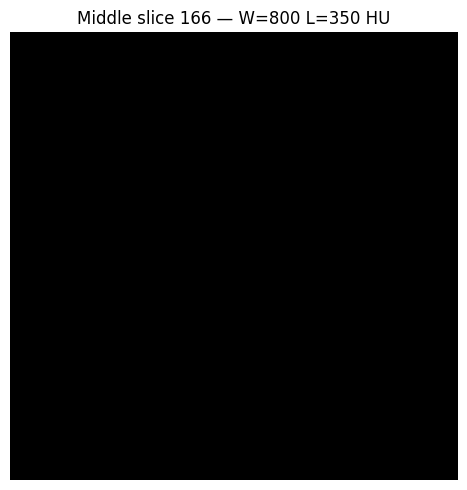

Preview saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\cmpr_RCA_Normal_1_preview.png


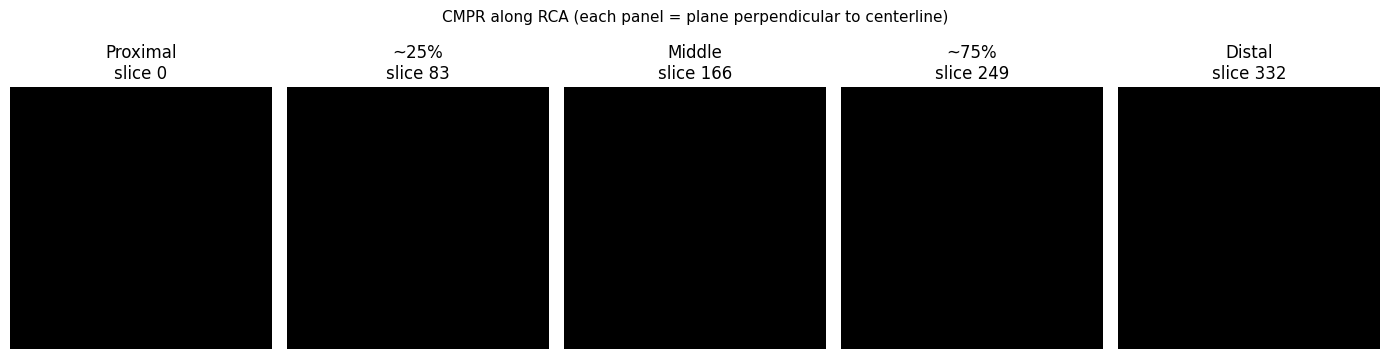

Montage saved: C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\notebooks\experiments\cmpr_RCA_Normal_1_montage.png


In [4]:
import numpy as np
import SimpleITK as sitk

CMPR_OUTPUT = EXPERIMENTS_DIR / "cmpr_RCA_Normal_1.nrrd"
CMPR_PREVIEW_PNG = EXPERIMENTS_DIR / "cmpr_RCA_Normal_1_preview.png"
CROP_CACHE_NRRD = DATA_DIR / "Normal_1_cmpr_crop.nrrd"
CENTERLINE_RESAMPLE_MM = 0.5
CROP_MARGIN_MM = 20.0
MIN_CROP_EXTENT_MM = 48.0
MAX_CROP_VOXELS_PER_AXIS = 220
INPLANE_SIZE = 64
INPLANE_SPACING_MM = 0.5
CT_BACKGROUND_HU = -1024.0
# Display: soft-tissue / coronary-style window (adjust if image looks too dark/flat)
CMPR_DISPLAY_CENTER_HU = 350.0
CMPR_DISPLAY_WIDTH_HU = 800.0
CMPR_MONTAGE_PNG = EXPERIMENTS_DIR / "cmpr_RCA_Normal_1_montage.png"


def _hu_to_display(hu: np.ndarray, center: float, width: float) -> np.ndarray:
    """Map HU to [0, 1] for grayscale display."""
    lo = center - width / 2
    hi = center + width / 2
    x = (hu.astype(np.float64) - lo) / (hi - lo)
    return np.clip(x, 0.0, 1.0)


def _clamp_index_extent(i0: int, i1: int, max_size: int, dim_max: int) -> tuple[int, int]:
    """Limit crop width so gzip slab loading stays within Jupyter memory."""
    size = i1 - i0 + 1
    if size <= max_size:
        return i0, i1
    center = (i0 + i1) // 2
    half = max_size // 2
    i0 = max(0, center - half)
    i1 = min(dim_max - 1, i0 + max_size - 1)
    i0 = max(0, i1 - max_size + 1)
    return i0, i1


def _ensure_min_extent_mm(
    i0: int,
    i1: int,
    spacing_axis: float,
    dim_max: int,
    min_mm: float,
) -> tuple[int, int]:
    """Expand a 1-voxel-thick crop so CMPR has enough in-plane context."""
    min_vox = max(16, int(np.ceil(min_mm / float(spacing_axis))))
    size = i1 - i0 + 1
    if size >= min_vox:
        return i0, i1
    center = (i0 + i1) // 2
    half = min_vox // 2
    i0 = max(0, center - half)
    i1 = min(dim_max - 1, i0 + min_vox - 1)
    i0 = max(0, i1 - min_vox + 1)
    return i0, i1


def _sitk_reference_from_reader(reader: sitk.ImageFileReader) -> sitk.Image:
    """Metadata-only SimpleITK image (for physical ↔ index transforms)."""
    ref = sitk.Image([int(v) for v in reader.GetSize()], sitk.sitkFloat32)
    ref.SetOrigin([float(v) for v in reader.GetOrigin()])
    ref.SetSpacing([float(v) for v in reader.GetSpacing()])
    ref.SetDirection(reader.GetDirection())
    return ref


def _points_to_index_extents(
    ref_img: sitk.Image,
    points_xyz: np.ndarray,
    margin_mm: float,
) -> tuple[tuple[int, int], tuple[int, int], tuple[int, int]]:
    """Map pipeline (Px, Py, Pz) mm coordinates to ITK index ranges."""
    pts = np.asarray(points_xyz, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 3:
        raise ValueError(f"Expected (N, 3) points, got {pts.shape}")

    from itertools import product

    indices = np.array(
        [ref_img.TransformPhysicalPointToIndex(tuple(p)) for p in pts],
        dtype=int,
    )
    spacing = np.array(ref_img.GetSpacing(), dtype=float)
    margin_vox = np.ceil(float(margin_mm) / spacing).astype(int)

    # Corner indices of the physical bounding box (rotated volumes).
    phys_min = pts.min(axis=0) - float(margin_mm)
    phys_max = pts.max(axis=0) + float(margin_mm)
    corner_indices = np.array(
        [ref_img.TransformPhysicalPointToIndex(tuple(c)) for c in product(*zip(phys_min, phys_max))],
        dtype=int,
    )
    indices = np.vstack([indices, corner_indices])

    print(
        "Index span (x,y,z): "
        + ", ".join(f"{indices[:, a].min()}-{indices[:, a].max()}" for a in range(3))
    )

    size_xyz = [int(v) for v in ref_img.GetSize()]
    extents = []
    for axis in range(3):
        lo = int(indices[:, axis].min() - margin_vox[axis])
        hi = int(indices[:, axis].max() + margin_vox[axis])
        lo = max(0, min(size_xyz[axis] - 1, lo))
        hi = max(0, min(size_xyz[axis] - 1, hi))
        if lo > hi:
            lo, hi = hi, lo
        lo, hi = _ensure_min_extent_mm(lo, hi, spacing[axis], size_xyz[axis], MIN_CROP_EXTENT_MM)
        extents.append((lo, hi))

    inside = 0
    for p in pts:
        try:
            ref_img.TransformPhysicalPointToIndex(tuple(p))
            inside += 1
        except RuntimeError:
            pass
    print(f"Centerline points inside volume: {inside}/{len(pts)}")
    if inside < max(10, 0.5 * len(pts)):
        raise RuntimeError(
            "Most centerline points fall outside the CT volume. "
            "Check that Normal_1.nrrd matches the Block 1/2 coordinate frame "
            "(ASOCA CTCA for the same patient)."
        )
    return extents[0], extents[1], extents[2]


def load_nrrd_cropped_for_points(
    path: Path,
    points_xyz: np.ndarray,
    margin_mm: float = CROP_MARGIN_MM,
) -> sitk.Image:
    """Load CT crop slab-by-slab (gzip-safe) using SimpleITK physical indexing."""
    if CROP_CACHE_NRRD.is_file():
        sitk_cached = sitk.ReadImage(str(CROP_CACHE_NRRD))
        nx, ny, nz = [int(v) for v in sitk_cached.GetSize()]
        if min(nx, ny, nz) >= 16:
            print(f"Using cached crop: {CROP_CACHE_NRRD.name} ({nx}×{ny}×{nz})")
            return sitk_cached
        print(f"Ignoring invalid cache ({nx}×{ny}×{nz}); rebuilding crop.")

    reader = sitk.ImageFileReader()
    reader.SetFileName(str(path))
    reader.ReadImageInformation()
    ref_img = _sitk_reference_from_reader(reader)

    size_xyz = [int(v) for v in reader.GetSize()]
    (x0, x1), (y0, y1), (z0, z1) = _points_to_index_extents(ref_img, points_xyz, margin_mm)

    x0, x1 = _clamp_index_extent(x0, x1, MAX_CROP_VOXELS_PER_AXIS, size_xyz[0])
    y0, y1 = _clamp_index_extent(y0, y1, MAX_CROP_VOXELS_PER_AXIS, size_xyz[1])
    z0, z1 = _clamp_index_extent(z0, z1, MAX_CROP_VOXELS_PER_AXIS, size_xyz[2])

    spacing_xyz = [float(v) for v in reader.GetSpacing()]
    origin_xyz = [float(v) for v in reader.GetOrigin()]

    nx, ny, nz = x1 - x0 + 1, y1 - y0 + 1, z1 - z0 + 1
    n_vox = nx * ny * nz
    if min(nx, ny, nz) < 16:
        raise RuntimeError(
            f"Degenerate crop ({nx}, {ny}, {nz}) after expansion — check CT/centerline alignment."
        )
    print(
        f"Crop index (x,y,z): [{x0}:{x1}], [{y0}:{y1}], [{z0}:{z1}] "
        f"-> size ({nx}, {ny}, {nz}) = {n_vox:,} voxels (~{n_vox * 4 / 1e6:.0f} MB float32)"
    )

    crop_origin = ref_img.TransformIndexToPhysicalPoint((int(x0), int(y0), int(z0)))

    # Slab-wise read along ITK z (gzip-friendly).
    volume = np.zeros((nz, ny, nx), dtype=np.float32)
    for k in range(nz):
        if k == 0 or (k + 1) % 25 == 0 or k == nz - 1:
            print(f"  reading axial slab {k + 1}/{nz}")
        slab_reader = sitk.ImageFileReader()
        slab_reader.SetFileName(str(path))
        slab_reader.ReadImageInformation()
        slab_reader.SetExtractIndex([x0, y0, z0 + k])
        slab_reader.SetExtractSize([nx, ny, 1])
        slab = sitk.GetArrayFromImage(slab_reader.Execute())
        volume[k] = slab[0]

    print("Building SimpleITK crop volume...")
    sitk_crop = sitk.GetImageFromArray(volume)
    sitk_crop.SetSpacing(tuple(spacing_xyz))
    sitk_crop.SetOrigin(tuple(crop_origin))
    sitk_crop.SetDirection(ref_img.GetDirection())
    del volume
    return sitk.Cast(sitk_crop, sitk.sitkFloat32)


def _unit(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v


def _safe_normal(v: np.ndarray, ref: np.ndarray | None = None) -> np.ndarray:
    if ref is None:
        ref = np.array([0.0, 0.0, 1.0], dtype=float)
    n = _unit(np.cross(v, ref))
    if np.linalg.norm(n) < 1e-6:
        ref = np.array([0.0, 1.0, 0.0], dtype=float)
        n = _unit(np.cross(v, ref))
    return n


def _parallel_transport_frames(tangents: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n = len(tangents)
    normals = np.zeros((n, 3), dtype=float)
    binormals = np.zeros((n, 3), dtype=float)
    normals[0] = _safe_normal(tangents[0])
    binormals[0] = _unit(np.cross(tangents[0], normals[0]))
    for i in range(1, n):
        b = _unit(np.cross(tangents[i - 1], tangents[i]))
        normals[i] = _unit(normals[i - 1] + b)
        normals[i] -= tangents[i] * np.dot(normals[i], tangents[i])
        normals[i] = _unit(normals[i])
        binormals[i] = _unit(np.cross(tangents[i], normals[i]))
    return normals, binormals


def resample_centerline_arc_length(xyz: np.ndarray, step_mm: float) -> np.ndarray:
    pts = np.asarray(xyz, dtype=float)
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    if s[-1] < 1e-6:
        raise ValueError("Centerline length is zero.")
    n_out = max(16, int(round(s[-1] / step_mm)) + 1)
    t = np.linspace(0.0, s[-1], n_out)
    return np.column_stack([np.interp(t, s, pts[:, i]) for i in range(3)])


def sample_cmpr_volume(
    sitk_img: sitk.Image,
    centerline_xyz: np.ndarray,
    out_spacing_mm: float,
    out_size: int,
    background: float = CT_BACKGROUND_HU,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Return (n_slices, out_size, out_size) CMPR volume and resampled centerline points."""
    from scipy.ndimage import map_coordinates

    pts = resample_centerline_arc_length(centerline_xyz, CENTERLINE_RESAMPLE_MM)
    seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    tangents = np.gradient(pts, s, axis=0, edge_order=1)
    tangents = np.nan_to_num(tangents / np.linalg.norm(tangents, axis=1, keepdims=True))

    n_slices = len(pts)
    normals, binormals = _parallel_transport_frames(tangents)

    half = (out_size // 2) * float(out_spacing_mm)
    u = np.linspace(-half, half, out_size)
    v = np.linspace(-half, half, out_size)
    U, V = np.meshgrid(u, v, indexing="ij")

    arr = sitk.GetArrayFromImage(sitk_img).astype(np.float32)
    out = np.full((n_slices, out_size, out_size), background, dtype=np.float32)

    for i in range(n_slices):
        if i == 0 or (i + 1) % 50 == 0 or i == n_slices - 1:
            print(f"  CMPR slice {i + 1}/{n_slices}", flush=True)
        center = pts[i]
        plane_phys = (
            center[None, None, :]
            + U[:, :, None] * normals[i]
            + V[:, :, None] * binormals[i]
        )
        coords = plane_phys.reshape(-1, 3)
        idx_xyz = np.array(
            [sitk_img.TransformPhysicalPointToContinuousIndex(tuple(p)) for p in coords],
            dtype=float,
        )
        # SimpleITK array is (z, y, x); continuous index is (x, y, z).
        idx = np.array([idx_xyz[:, 2], idx_xyz[:, 1], idx_xyz[:, 0]])
        out[i] = map_coordinates(
            arr,
            idx,
            order=1,
            mode="constant",
            cval=background,
        ).reshape(out_size, out_size)

    arc_mm = float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))
    return out, pts, arc_mm


def save_cmpr_sitk(
    cmpr: np.ndarray,
    origin_xyz: np.ndarray,
    direction: tuple,
    path: Path,
    slice_spacing_mm: float,
    inplane_spacing_mm: float,
) -> None:
    sitk_out = sitk.GetImageFromArray(cmpr)
    sitk_out.SetSpacing([inplane_spacing_mm, inplane_spacing_mm, slice_spacing_mm])
    sitk_out.SetOrigin(tuple(origin_xyz))
    sitk_out.SetDirection(direction)
    sitk.WriteImage(sitk_out, str(path), useCompression=False)


rca_points_xyz = df_rca[["Px", "Py", "Pz"]].to_numpy(dtype=float)
print(
    f"RCA path coordinate ranges (mm): "
    f"Px [{rca_points_xyz[:, 0].min():.1f}, {rca_points_xyz[:, 0].max():.1f}], "
    f"Py [{rca_points_xyz[:, 1].min():.1f}, {rca_points_xyz[:, 1].max():.1f}], "
    f"Pz [{rca_points_xyz[:, 2].min():.1f}, {rca_points_xyz[:, 2].max():.1f}]"
)

import matplotlib.pyplot as plt

print(f"Loading cropped CT around RCA path (+{CROP_MARGIN_MM} mm margin)...", flush=True)
sitk_crop = load_nrrd_cropped_for_points(NRRD_PATH, rca_points_xyz, margin_mm=CROP_MARGIN_MM)

try:
    sitk.WriteImage(sitk_crop, str(CROP_CACHE_NRRD), useCompression=False)
    print(f"Cached crop -> {CROP_CACHE_NRRD.name}")
except Exception as exc:
    print(f"Cache write skipped ({exc})")

print("Building CMPR along RCA centerline...", flush=True)
cmpr_vol, cl_pts, path_len_mm = sample_cmpr_volume(
    sitk_crop,
    rca_points_xyz,
    out_spacing_mm=INPLANE_SPACING_MM,
    out_size=INPLANE_SIZE,
    background=CT_BACKGROUND_HU,
)

save_cmpr_sitk(
    cmpr_vol,
    origin_xyz=tuple(cl_pts[0]),
    direction=tuple(sitk_crop.GetDirection()),
    path=CMPR_OUTPUT,
    slice_spacing_mm=path_len_mm / max(cmpr_vol.shape[0] - 1, 1e-6),
    inplane_spacing_mm=INPLANE_SPACING_MM,
)

print(f"CMPR saved to: {CMPR_OUTPUT}")
print(f"  Volume shape (slices × H × W): {cmpr_vol.shape}")
print(f"  Resampled centerline arc length: {path_len_mm:.1f} mm")

nz = cmpr_vol.shape[0]
mid = nz // 2
sl_mid = cmpr_vol[mid]
print(
    f"  Middle slice HU stats: min={sl_mid.min():.1f}, max={sl_mid.max():.1f}, "
    f"mean={sl_mid.mean():.1f}"
)

# Raw HU uses full dynamic range → often looks black in Jupyter; use W/L like a CT viewer.
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(
    _hu_to_display(sl_mid, CMPR_DISPLAY_CENTER_HU, CMPR_DISPLAY_WIDTH_HU),
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1,
)
ax.set_title(
    f"Middle slice {mid} — W={CMPR_DISPLAY_WIDTH_HU:.0f} L={CMPR_DISPLAY_CENTER_HU:.0f} HU"
)
ax.axis("off")
plt.tight_layout()
plt.savefig(CMPR_PREVIEW_PNG, dpi=120)
plt.show()
print(f"Preview saved: {CMPR_PREVIEW_PNG}")

idxs = [0, nz // 4, nz // 2, (3 * nz) // 4, nz - 1]
labels = ["Proximal", "~25%", "Middle", "~75%", "Distal"]
fig_m, axes_m = plt.subplots(1, len(idxs), figsize=(14, 3.5))
for ax_m, j, lab in zip(axes_m, idxs, labels):
    disp = _hu_to_display(cmpr_vol[j], CMPR_DISPLAY_CENTER_HU, CMPR_DISPLAY_WIDTH_HU)
    ax_m.imshow(disp, cmap="gray", origin="lower", vmin=0, vmax=1)
    ax_m.set_title(f"{lab}\nslice {j}")
    ax_m.axis("off")
fig_m.suptitle(
    "CMPR along RCA (each panel = plane perpendicular to centerline)",
    fontsize=11,
    y=1.05,
)
plt.tight_layout()
plt.savefig(CMPR_MONTAGE_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Montage saved: {CMPR_MONTAGE_PNG}")